# Introduction

## MVTec Anomaly Detection

[MVTec AD](https://www.mvtec.com/research-teaching/datasets/mvtec-ad) is a dataset for benchmarking anomaly detection with a focus on industrial inspection. In total, it contains over 5000 high-res images divided into 15 different objects/texture categories consisting of normal, defect-free images intended for training and images with defects for testing. In addition, the dataset provides pixel-precise ground truth for all anamolies.

The goal for this project is NOT to create a state-of-the-art anomaly detector, but rather build a Post-Training Quantization (PTQ) pipeline. We want to see if quantization will degrade the model's ability to correctly detect anomalies and visualize its effect on different layers.

## Why Quantization?

There are two places an AI model can run:

1. **Cloud**: Data is sent over the internet to a powerful server, processed, and results are sent back.
2. **Edge**: Computing happens on the device itself, no internet required.

(write a simple summary)

You can read more [here](https://www.mvtec.com/research-teaching/datasets/mvtec-ad)



# 1.1 Pre-requisites

Please ensure the proper versions are downloaded, which can be found in requirements.txt.

In [1]:
import math
import time
import io
import numpy as np
import csv
from IPython.display import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

print(torch.__version__)

import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

%load_ext autoreload
%autoreload 2

2.6.0+cu124


In [2]:
# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device: %s" % device)

Device: cuda


# 1.2 Dataset Setup and Exploration

In [3]:
# Dataset location
MVT_ROOT = Path("C:/Users/dkim2/Desktop/projects/edge_anomaly/data")
CAT = 'bottle'
DATA_PATH = MVT_ROOT / CAT

# Verify
assert DATA_PATH.exists(), f"{DATA_PATH}\n NOT FOUND"

### 1.2.1 Quick Resolution Verification

In [8]:
img_path = DATA_PATH / "train" / "good" / "000.png"
sample_img = Image.open(img_path)

print(f"Res: {sample_img.size}")
print(f"Mode: {sample_img.mode}")

Res: (900, 900)
Mode: RGB


Downscale to 256x256 and visually verify anomalies are identifiable.

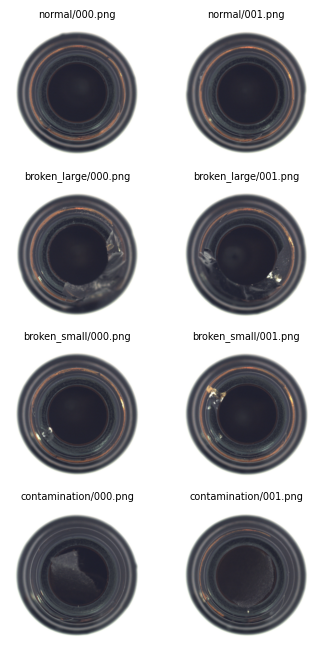

In [35]:
IMG_SIZE = 256

def load_and_resize(category_path: Path, split: str, subfolder: str, size: int, n: int):

    folder = category_path / split / subfolder
    paths = sorted(folder.glob("*.png"))[:n]
    images = [Image.open(path).resize((size, size), Image.BILINEAR) for path in paths]

    return images, [p.name for p in paths]


# Load normal and all anomaly types 256x256
norm_resized, norm_names = load_and_resize(DATA_PATH, "train", "good", size=IMG_SIZE, n=2)

# Anomaly types
anomaly_types = sorted([path.name for path in (DATA_PATH / "test").iterdir() if path.is_dir() and path.name != "good"])

n_cols = 2 # 2 samples per
n_rows = 1 + len(anomaly_types)  # normal row + one row per anomaly type

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

# Normal row
for i, (img, name) in enumerate(zip(norm_resized, norm_names)):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"normal/{name}", fontsize=7)
    axes[0, i].axis("off")

# One row per anomaly
for row, anomaly_type in enumerate(anomaly_types, start=1):
    anom_resized, anom_names = load_and_resize(DATA_PATH, "test", anomaly_type, size=IMG_SIZE, n=2)

    for i, (img, name) in enumerate(zip(anom_resized, anom_names)):
        axes[row, i].imshow(img)
        axes[row, i].set_title(f"{anomaly_type}/{name}", fontsize=7)
        axes[row, i].axis("off")

plt.show()

# 2. Convolution Neural Network

There are two gradients that matter during the backward pass.

1. **Gradient w.r.t weights (how to update kernel)**
$$
\begin{align}
\frac{\partial L}{\partial K[m, n]} = \sum \sum \frac{\partial L}{\partial Out[i, j]} * H[i+m, j+n]
\end{align}
$$

For each kernel weight $K[m,n]$, find every input position it touched during the forward pass and add how much each contributed to the loss. It's essentially the convolution between the input and the upstream gradient.

2. **Gradient w.r.t input (passing loss back to prev. layer)**
$$
\begin{align}
\frac{\partial L}{\partial H[i, j]} = \sum \sum \frac{\partial L}{\partial Out[i, j]} * K[m, n]
\end{align}
$$

For each input pixel, find every output it contributed to and add how much it affected the loss. This is the full convolution.



## 2.1 Quantization Error

### 2.1.1 Weights
From the two equations, we see that both gradients depend directly on $K$ (kernel weights). During quantization, if $K$ is compressed from float32 (32-bit precision) to int8 (256 discreet values), both weight update and backpass information will be affected. The quantization error is the difference between the original and reconstructed. 
$$
\begin{gather}
\text{scale} = \frac{K_{\text{float}}^{\max} - K_{\text{float}}^{\min}}{255}; \quad \text{center} = \text{round}\left(-\frac{K^{\text{min}}}{\text{scale}}\right)\\
K_{\text{int}} = \text{round}\left(\frac{K_{\text{float}}}{\text{scale}}\right) + \text{center}\\
K_{\text{approx}} = \text{scale} * (K_{\text{int}} - \text{center})\\
\text{error} = K_\text{float} - K_\text{approx}
\end{gather}
$$

### 2.1.2 Activation

Let's look at a simple case of activation after convolution `ReLU(conv(input, kernel))`. While weight ranges are fixed after training, activation ranges depends on the `input`, meaning that it changes with every sample. 

There are 3 ways of dealing with this. Post-Training Quantization (PTQ), Quantization-Aware Training (QAT), and Dynamic Quantization (DQ). QAT simulates the quantization noise during training s.t. the model will be robust to it, but at the cost of computation, as the model will need to be retrained. DQ computes ranges during runtime, at the cost of speed.

This notebook will focus on PTQ. Rather than retraining or computing during run time, PTQ uses a calibration dataset, where you run a sample of inputs through the model, record the activation ranges at each layer, then use those to set the parameters.

# Citations

https://www.cs.toronto.edu/~hinton/absps/science.pdf
https://arxiv.org/pdf/1312.6114
